In [1]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt


In [4]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from tkinter import Tk
from tkinter.filedialog import askopenfilename

Tk().withdraw()
print("Select train.csv file")
train_path = askopenfilename()
print("Select val.csv file")
val_path = askopenfilename()

train = pd.read_csv(train_path)
val = pd.read_csv(val_path)

X_train = train.drop("label_move_col", axis=1)
y_train = train["label_move_col"]

X_val = val.drop("label_move_col", axis=1)
y_val = val["label_move_col"]

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)



Select train.csv file
The history saving thread hit an unexpected error (OperationalError('database or disk is full')).History will not be written to the database.
Select val.csv file


In [6]:
# 3. Split features and labels
X_train = train.drop("label_move_col", axis=1)
y_train = train["label_move_col"]

X_val = val.drop("label_move_col", axis=1)
y_val = val["label_move_col"]

# Normalize data
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)

print("Data ready:", X_train.shape, y_train.shape)


Data ready: (10774, 43) (10774,)


In [7]:
from tensorflow import keras
from tensorflow.keras import layers

model = keras.Sequential([
    layers.Input(shape=(43,)),
    layers.Dense(128, activation='relu'),
    layers.Dense(64, activation='relu'),
    layers.Dense(32, activation='relu'),
    layers.Dense(7, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 128)            │         5,632 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 7)              │           231 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 16,199 (63.28 KB)

 Trainable params: 16,199 (63.28 KB)

 Non-trainable params: 0 (0.00 B)

In [8]:
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=10,
    batch_size=32,
    verbose=1
)


Epoch 1/10
337/337 ━━━━━━━━━━━━━━━━━━━━ 10s 11ms/step - accuracy: 0.3648 - loss: 1.7683 - val_accuracy: 0.3660 - val_loss: 1.7006
Epoch 2/10
337/337 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.4055 - loss: 1.5950 - val_accuracy: 0.3907 - val_loss: 1.6252
Epoch 3/10
337/337 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.4468 - loss: 1.4779 - val_accuracy: 0.4168 - val_loss: 1.5676
Epoch 4/10
337/337 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.4942 - loss: 1.3752 - val_accuracy: 0.4379 - val_loss: 1.5336
Epoch 5/10
337/337 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.5266 - loss: 1.2927 - val_accuracy: 0.4435 - val_loss: 1.5273
Epoch 6/10
337/337 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.5527 - loss: 1.2215 - val_accuracy: 0.4564 - val_loss: 1.5268
Epoch 7/10
337/337 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - accuracy: 0.5750 - loss: 1.1531 - val_accuracy: 0.4631 - val_loss: 1.5237
Epoch 8/10
337/337 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.5997 - loss: 1.0993 - val_acc

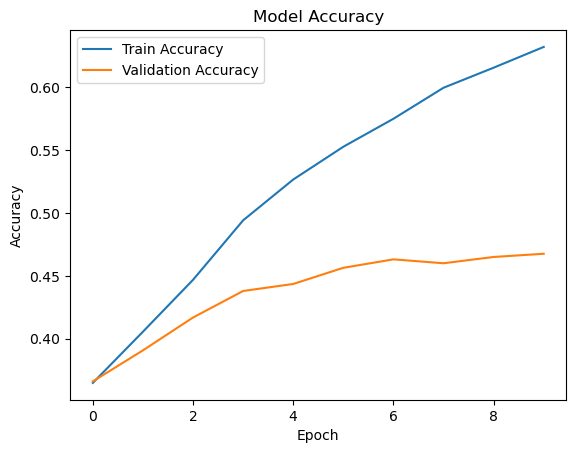

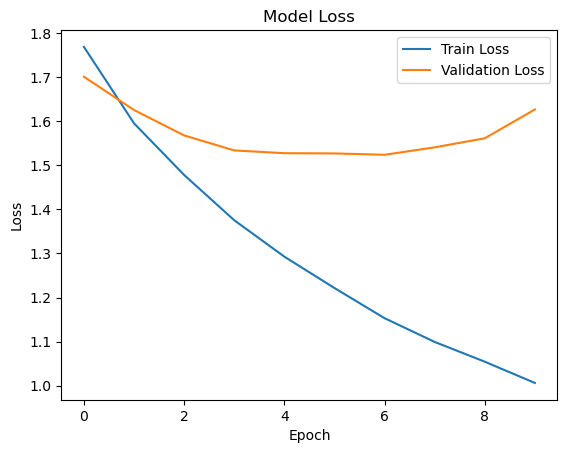

In [9]:
import matplotlib.pyplot as plt

# Plot accuracy
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

# Plot loss
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()


In [10]:
val_loss, val_acc = model.evaluate(X_val, y_val, verbose=0)
print(f"Validation Accuracy: {val_acc:.4f}")
print(f"Validation Loss: {val_loss:.4f}")


Validation Accuracy: 0.4676
Validation Loss: 1.6264
